# 🏦 Bank Marketing Campaign:- ML Project
### Predicting Term Deposit Subscriptions
**Data Sciences Institute | Cohort 8 | Machine Learning Systems**

---
**Dataset:** UCI Bank Marketing Dataset (45,211 records, 16 features)  
**Goal:** Predict whether a client will subscribe to a term deposit and optimise campaign targeting.

---

### 📋 Notebook Structure
| # | Section |
|---|---|
| 1 | Setup & Imports |
| 2 | Data Loading & Inspection |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Preprocessing Pipeline |
| 5 | Model Training |
| 6 | Model Evaluation |
| 7 | Feature Importance |
| 8 | Segment & Decile Analysis |
| 9 | Business Impact Analysis |
| 10 | Fairness Audit |
| 11 | Summary & Recommendations |

---
## 1. Setup & Imports
Run this cell first. Install any missing packages using the commented pip commands.

In [ ]:
# !pip install pandas numpy matplotlib scikit-learn xgboost shap imbalanced-learn

In [1]:
# ──── Core ────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ──── Visualisation ────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

# ──── Machine Learning ────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
import shap

In [2]:
# ────────────────── File path ──────────────────
DATA_PATH = '../data/processed/bank_cleaned.csv'   

import os
os.makedirs('outputs', exist_ok=True)

print('\n✅ All imports complete.')


✅ All imports complete.


---
## 2. Data Loading & Inspection

In [3]:
df = pd.read_csv(DATA_PATH)

print(f'Shape: {df.shape}')
print(f'\nColumn names:\n{list(df.columns)}')
df.head()

Shape: (45211, 16)

Column names:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'campaign', 'previous', 'poutcome', 'y', 'previously_contacted']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,y,previously_contacted
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,unknown,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,unknown,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,unknown,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,unknown,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,0,unknown,0,0


In [4]:
# Data types and missing values
info = pd.DataFrame({
    'dtype'  : df.dtypes,
    'missing': df.isnull().sum(),
    'unique' : df.nunique()
})
print(info)

                      dtype  missing  unique
age                   int64        0      77
job                     str        0      12
marital                 str        0       3
education               str        0       4
default                 str        0       2
balance               int64        0    7168
housing                 str        0       2
loan                    str        0       2
contact                 str        0       3
day                   int64        0      31
month                   str        0      12
campaign              int64        0      48
previous              int64        0      41
poutcome                str        0       4
y                     int64        0       2
previously_contacted  int64        0       2


In [5]:
# Numeric summary
df.describe().round(2)

,age,balance,day,campaign,previous,y,previously_contacted
count,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00,45211.00
mean,40.94,1362.27,15.81,2.76,0.58,0.12,0.18
std,10.62,3044.77,8.32,3.10,2.30,0.32,0.39
min,18.00,-8019.00,1.00,1.00,0.00,0.00,0.00
25%,33.00,72.00,8.00,1.00,0.00,0.00,0.00
50%,39.00,448.00,16.00,2.00,0.00,0.00,0.00
75%,48.00,1428.00,21.00,3.00,0.00,0.00,0.00
max,95.00,102127.00,31.00,63.00,275.00,1.00,1.00


In [6]:
# Target variable distribution
counts = df['y'].value_counts()
pct    = df['y'].value_counts(normalize=True) * 100

print('Target variable distribution:')
print(f'  No  (0): {counts[0]:,}  ({pct[0]:.1f}%)')
print(f'  Yes (1): {counts[1]:,}  ({pct[1]:.1f}%)')
print(f'\nClass ratio (no:yes): {counts[0]/counts[1]:.1f}:1')

Target variable distribution:
  No  (0): 39,922  (88.3%)
  Yes (1): 5,289  (11.7%)

Class ratio (no:yes): 7.5:1


---
## 3. Exploratory Data Analysis (EDA)

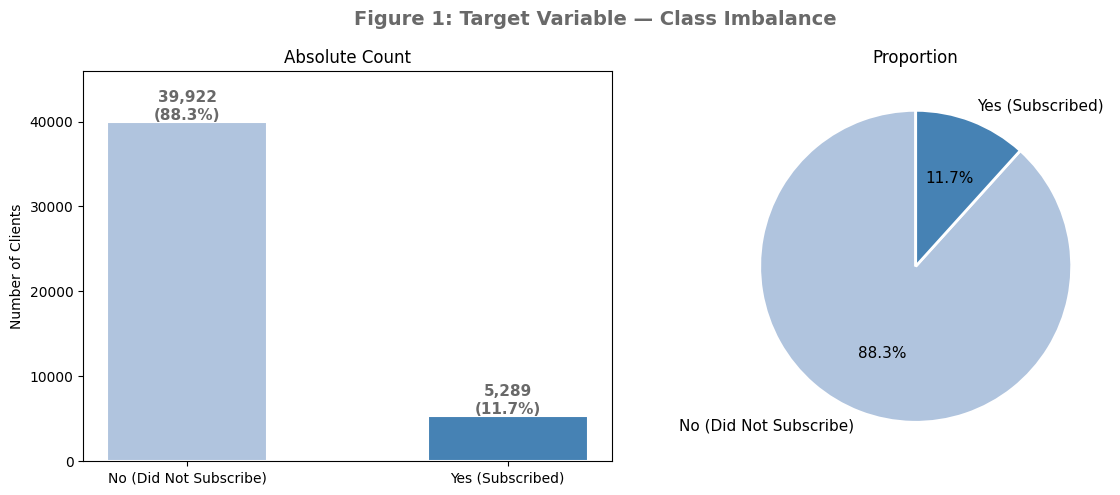

In [12]:
# ───────────────────────────────── Figure 1: Class Imbalance ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Figure 1: Target Variable — Class Imbalance', fontsize=14, fontweight='bold', color='dimgray')

labels = ['No (Did Not Subscribe)', 'Yes (Subscribed)']
colors = ['lightsteelblue', 'steelblue']

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 300, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center',
                 fontsize=11, color='dimgray', fontweight='bold')
axes[0].set_title('Absolute Count')
axes[0].set_ylabel('Number of Clients')
axes[0].set_ylim(0, max(counts.values) * 1.15)

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11},
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('outputs/fig1_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

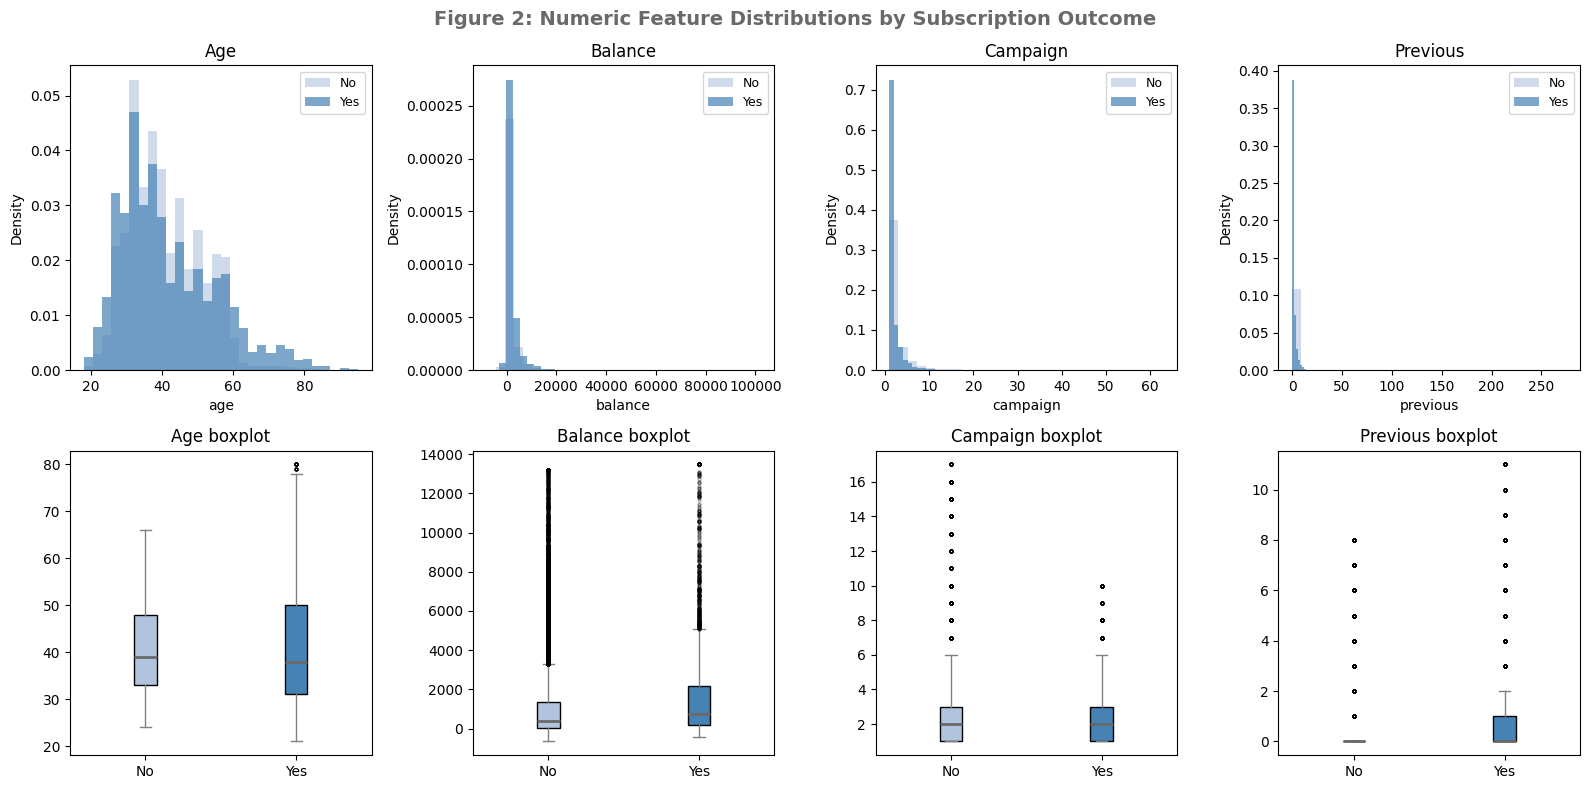

In [13]:
# ───────────────────────────────── Figure 2: Numeric Distributions by Outcome ─────────────────────────────────
numeric_cols = ['age', 'balance', 'campaign', 'previous']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Figure 2: Numeric Feature Distributions by Subscription Outcome',
             fontsize=14, fontweight='bold', color='dimgray')

for i, col in enumerate(numeric_cols):
    sub_no  = df[df['y'] == 0][col]
    sub_yes = df[df['y'] == 1][col]

    # Histogram (density)
    ax = axes[0, i]
    ax.hist(sub_no,  bins=30, alpha=0.6, color='lightsteelblue', label='No',  edgecolor='none', density=True)
    ax.hist(sub_yes, bins=30, alpha=0.7, color='steelblue',      label='Yes', edgecolor='none', density=True)
    ax.set_title(col.capitalize())
    ax.set_xlabel(col)
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

    # Boxplot (trimmed to 1st–99th percentile)
    ax2 = axes[1, i]
    data_trimmed = [
        sub_no.clip(sub_no.quantile(0.01),   sub_no.quantile(0.99)),
        sub_yes.clip(sub_yes.quantile(0.01), sub_yes.quantile(0.99))
    ]
    bp = ax2.boxplot(data_trimmed, patch_artist=True,
                     medianprops={'color': 'dimgray',  'linewidth': 2},
                     whiskerprops={'color': 'gray'},
                     capprops={'color': 'gray'},
                     flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3, 'color': 'gray'})
    bp['boxes'][0].set_facecolor('lightsteelblue')
    bp['boxes'][1].set_facecolor('steelblue')
    ax2.set_xticklabels(['No', 'Yes'])
    ax2.set_title(f'{col.capitalize()} boxplot')

plt.tight_layout()
plt.savefig('outputs/fig2_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

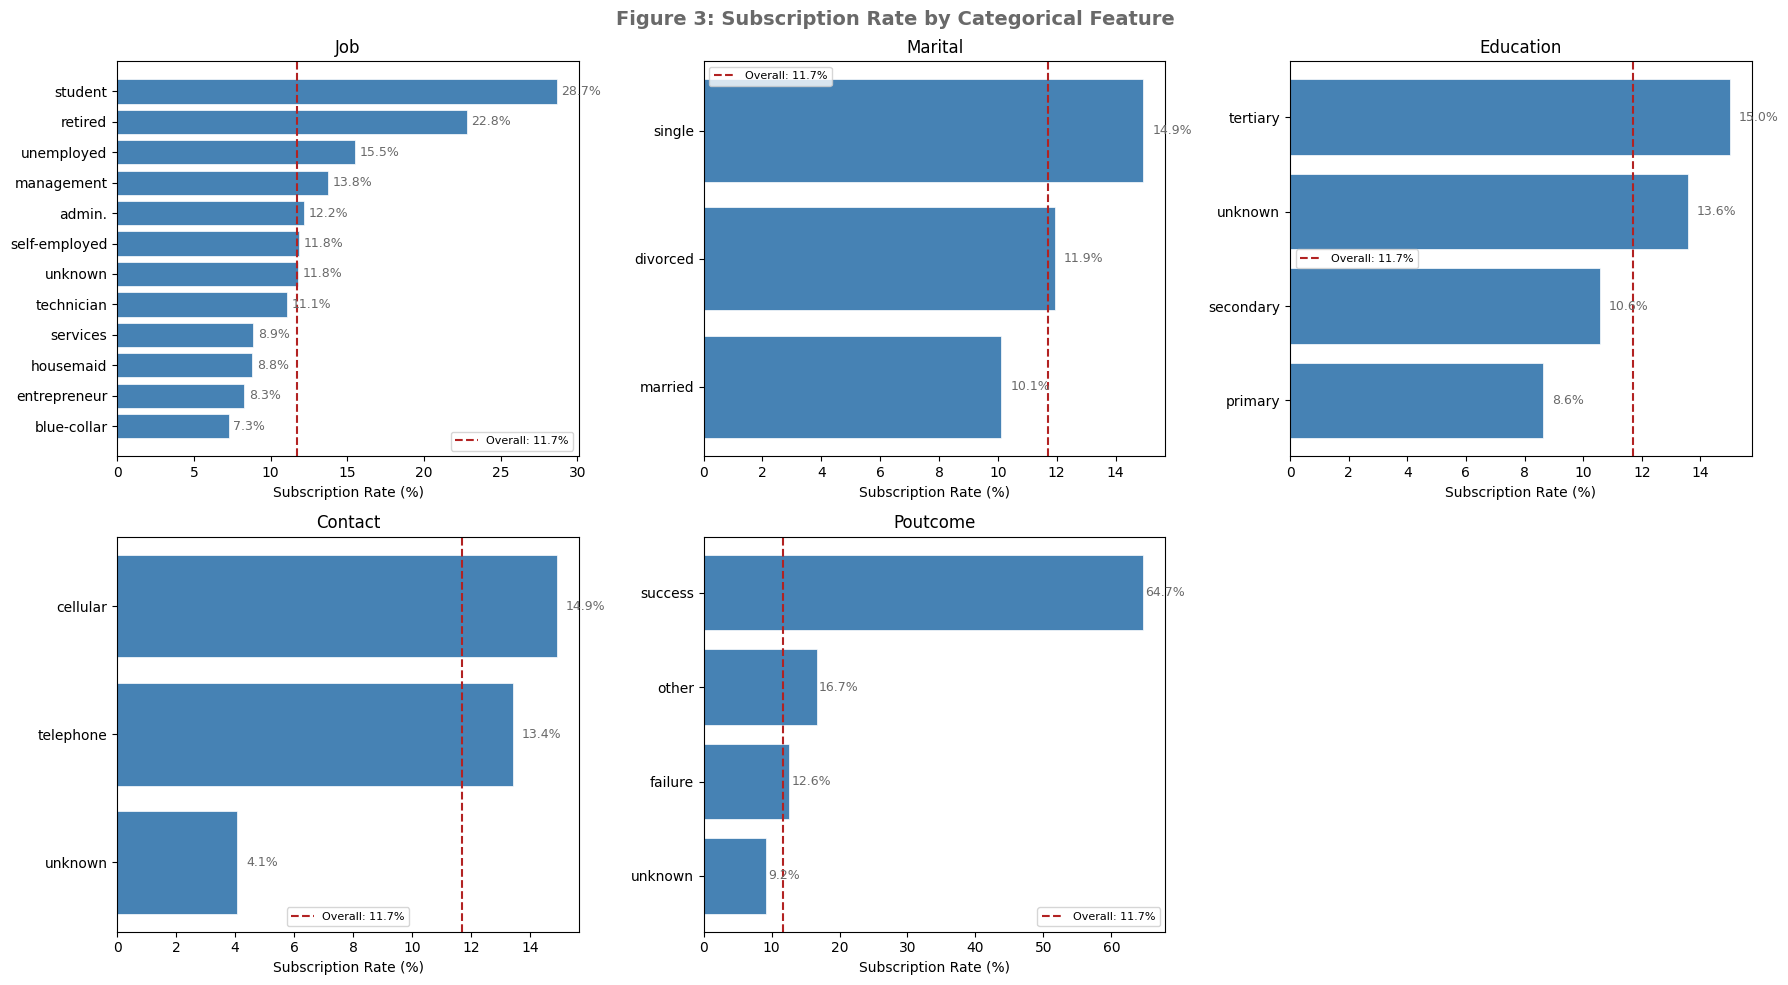

In [14]:
# ───────────────────────────────── Figure 3: Categorical Subscription Rates ─────────────────────────────────
cat_cols = ['job', 'marital', 'education', 'contact', 'poutcome']
baseline = df['y'].mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 3: Subscription Rate by Categorical Feature',
             fontsize=14, fontweight='bold', color='dimgray')
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    rate = df.groupby(col)['y'].mean().sort_values(ascending=True) * 100
    bars = axes_flat[i].barh(rate.index, rate.values, color='steelblue',
                              edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, rate.values):
        axes_flat[i].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                          f'{val:.1f}%', va='center', fontsize=9, color='dimgray')
    axes_flat[i].axvline(baseline * 100, color='firebrick', linestyle='--',
                          linewidth=1.5, label=f'Overall: {baseline*100:.1f}%')
    axes_flat[i].set_title(col.replace('_', ' ').title())
    axes_flat[i].set_xlabel('Subscription Rate (%)')
    axes_flat[i].legend(fontsize=8)

axes_flat[5].set_visible(False)
plt.tight_layout()
plt.savefig('outputs/fig3_categorical_rates.png', dpi=150, bbox_inches='tight')
plt.show()

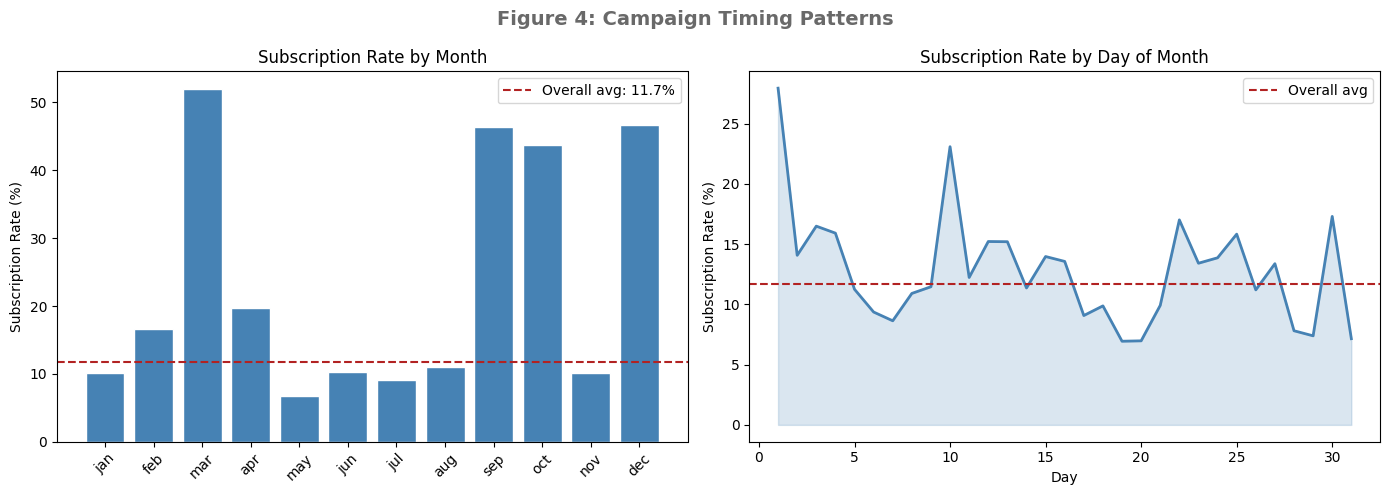

In [16]:
# ───────────────────────────────── Figure 4: Campaign Timing ─────────────────────────────────
month_order = ['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec']
month_rate  = df.groupby('month')['y'].mean().reindex(month_order).dropna() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4: Campaign Timing Patterns', fontsize=14, fontweight='bold', color='dimgray')

axes[0].bar(range(len(month_rate)), month_rate.values, color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(month_rate)))
axes[0].set_xticklabels(month_rate.index, rotation=45)
axes[0].axhline(baseline * 100, color='firebrick', linestyle='--', linewidth=1.5,
                label=f'Overall avg: {baseline*100:.1f}%')
axes[0].set_title('Subscription Rate by Month')
axes[0].set_ylabel('Subscription Rate (%)')
axes[0].legend()

day_rate = df.groupby('day')['y'].mean() * 100
axes[1].plot(day_rate.index, day_rate.values, color='steelblue', linewidth=2)
axes[1].fill_between(day_rate.index, day_rate.values, alpha=0.2, color='steelblue')
axes[1].axhline(baseline * 100, color='firebrick', linestyle='--', linewidth=1.5, label='Overall avg')
axes[1].set_title('Subscription Rate by Day of Month')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Subscription Rate (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/fig4_timing_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

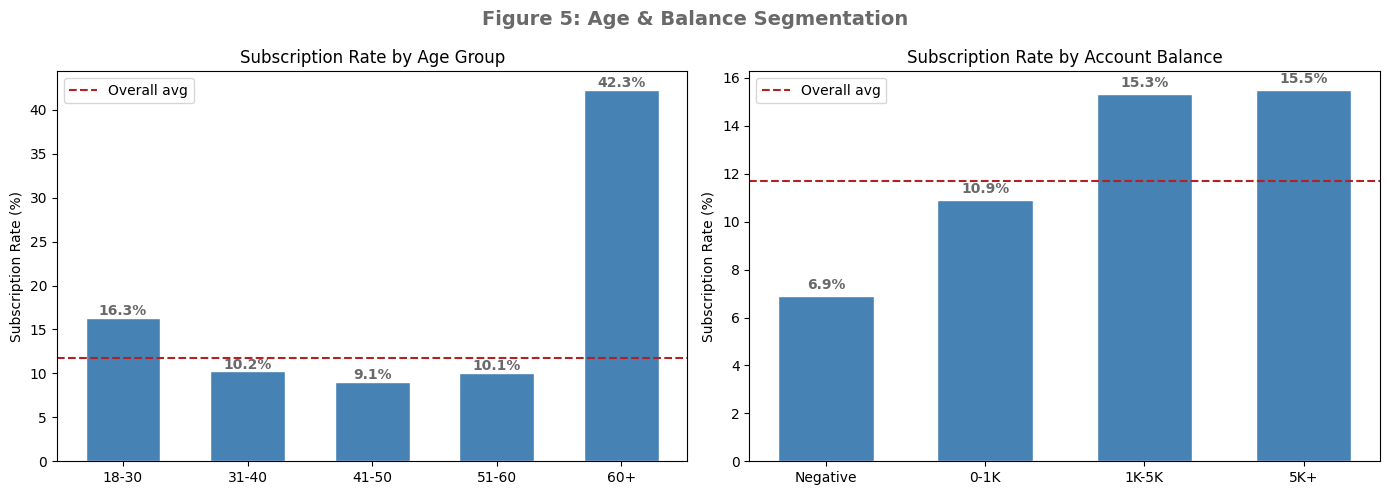


📊 Key EDA Insights:
  60+ age group subscribe at: 42.3% (36.1x average)
  Clients with 5K+ balance:   15.5%
  poutcome=success rate:       ~65% (from Fig 3)


In [17]:
# ───────────────────────────────── Figure 5: Age & Balance Segmentation ─────────────────────────────────
df['age_group']     = pd.cut(df['age'],     bins=[17, 30, 40, 50, 60, 100],
                              labels=['18-30', '31-40', '41-50', '51-60', '60+'])
df['balance_group'] = pd.cut(df['balance'], bins=[-10000, 0, 1000, 5000, 200000],
                              labels=['Negative', '0-1K', '1K-5K', '5K+'])

age_rate = df.groupby('age_group',     observed=True)['y'].mean() * 100
bal_rate = df.groupby('balance_group', observed=True)['y'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 5: Age & Balance Segmentation', fontsize=14, fontweight='bold', color='dimgray')

for ax, rate, title in zip(axes, [age_rate, bal_rate],
                            ['Subscription Rate by Age Group',
                             'Subscription Rate by Account Balance']):
    ax.bar(rate.index, rate.values, color='steelblue', edgecolor='white', width=0.6)
    ax.axhline(baseline * 100, color='firebrick', linestyle='--', linewidth=1.5, label='Overall avg')
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=10,
                color='dimgray', fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Subscription Rate (%)')
    ax.legend()

plt.tight_layout()
plt.savefig('outputs/fig5_age_balance_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Key EDA Insights:')
print(f'  60+ age group subscribe at: {age_rate["60+"]:.1f}% ({age_rate["60+"]/baseline/10:.1f}x average)')
print(f'  Clients with 5K+ balance:   {bal_rate["5K+"]:.1f}%')
print(f'  poutcome=success rate:       ~65% (from Fig 3)')

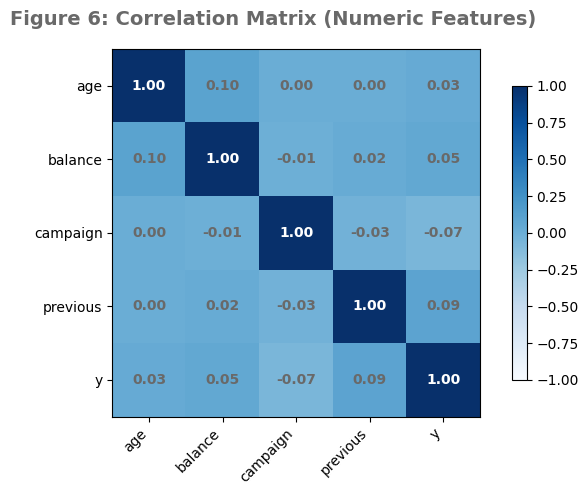


Correlation with target (y):
previous    0.093236
balance     0.052838
age         0.025155
campaign   -0.073172
Name: y, dtype: float64


In [ ]:
# ───────────────────────────────── Figure 6: Correlation Matrix ─────────────────────────────────
num_df = df[['age', 'balance', 'campaign', 'previous', 'y']].copy()
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle('Figure 6: Correlation Matrix (Numeric Features)',
             fontsize=14, fontweight='bold', color='dimgray')

im = ax.imshow(corr, cmap='Blues', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr.iloc[i, j]) > 0.5 else 'dimgray',
                fontsize=10, fontweight='bold')

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('outputs/fig6_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with target (y):')
print(corr['y'].drop('y').sort_values(ascending=False))

---
## 4. Preprocessing Pipeline

Steps:
1. Drop `duration` (data leakage: because only known after the call ends)
2. Binary encode yes/no columns
3. One-hot encode nominal categoricals
4. Stratified 70 / 15 / 15 train-val-test split
5. StandardScaler for Logistic Regression only

In [23]:
# ───────────────────────────────── 4.1 Copy and clean ─────────────────────────────────
df_model = df.copy()

# Drop leakage and segment columns
drop_cols = ['duration', 'age_group', 'balance_group']
df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)

# ───────────────────────────────── 4.2 Binary encode yes/no columns FIRST (before anything else) ─────────────────────────────────
binary_cols = ['default', 'housing', 'loan']
for col in binary_cols:
    df_model[col] = (df_model[col].astype(str).str.strip().str.lower() == 'yes').astype(int)

# ───────────────────────────────── 4.3 One-hot encode nominal categoricals ─────────────────────────────────
cat_cols_encode = ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
df_model = pd.get_dummies(df_model, columns=cat_cols_encode, drop_first=False)

# Convert any bool columns to int (pandas 3.x returns bool from get_dummies)
for col in df_model.select_dtypes(include='bool').columns:
    df_model[col] = df_model[col].astype(int)

# ───────────────────────────────── Safety check: flag any remaining non-numeric columns ─────────────────────────────────
non_numeric = df_model.select_dtypes(exclude='number').columns.tolist()
if non_numeric:
    print(f'⚠️  Non-numeric columns still present: {non_numeric}')
    print('    Forcing conversion...')
    for col in non_numeric:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce').fillna(0).astype(int)
else:
    print(f'✅ All columns numeric. Shape: {df_model.shape}')
    print(f'   Total features: {df_model.shape[1] - 1}')

df_model.head(2)

✅ All columns numeric. Shape: (45211, 48)
   Total features: 47


,age,default,balance,housing,loan,day,campaign,previous,y,previously_contacted,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,44,0,29,1,0,5,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1


In [24]:
# ───────────────────────────────── 4.4 Train / Validation / Test split (70 / 15 / 15 stratified) ─────────────────────────────────
X = df_model.drop('y', axis=1)
y = df_model['y']

# First split: hold out 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
# Second split: from remaining 85%, hold out ~17.6% → gives 15% of total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print('Split sizes:')
print(f'  Train : {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)  — positive rate: {y_train.mean():.3f}')
print(f'  Val   : {len(X_val):,}  ({len(X_val)/len(X)*100:.1f}%)  — positive rate: {y_val.mean():.3f}')
print(f'  Test  : {len(X_test):,}  ({len(X_test)/len(X)*100:.1f}%)  — positive rate: {y_test.mean():.3f}')

# ───────────────────────────────── 4.5 Scaling (for Logistic Regression only) ─────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit on train only
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# Class imbalance ratio
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'\nClass weight ratio (neg/pos): {ratio:.2f}')
print('Note: Using class_weight="balanced" for LR and RF.')
print('      GBM uses subsample and depth regularisation instead.')

Split sizes:
  Train : 31,646 (70.0%)  — positive rate: 0.117
  Val   : 6,783  (15.0%)  — positive rate: 0.117
  Test  : 6,782  (15.0%)  — positive rate: 0.117

Class weight ratio (neg/pos): 7.55
Note: Using class_weight="balanced" for LR and RF.
      GBM uses subsample and depth regularisation instead.


---
## 5. Model Training

Three models in order of complexity:
- **Logistic Regression** → interpretable baseline
- **Random Forest** → ensemble, handles non-linearity
- **Gradient Boosting / XGBoost** → primary model, best performance expected

For each model we will:
1. Train on the training set
2. Search for the best decision threshold on the validation set (maximise F1)
3. Evaluate final performance on the held-out test set

In [25]:
# ───────────────────────────────── Define models ─────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42, C=1.0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        max_depth=15, min_samples_leaf=10,
        random_state=42, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=ratio,
        random_state=42, eval_metric='logloss', verbosity=0
    )
}

print(f'Models to train: {list(models.keys())}')

Models to train: ['Logistic Regression', 'Random Forest', 'XGBoost']


In [26]:
# ───────────────────────────────── Train, threshold-tune, evaluate ─────────────────────────────────
results       = {}
fitted_models = {}
thresholds    = np.linspace(0.05, 0.95, 91)

for name, model in models.items():
    print(f'\n{"─"*50}')
    print(f'Training: {name}')

    # Only Logistic Regression uses scaled data
    use_scaled = (name == 'Logistic Regression')
    X_tr = X_train_sc if use_scaled else X_train
    X_v  = X_val_sc   if use_scaled else X_val
    X_te = X_test_sc  if use_scaled else X_test

    model.fit(X_tr, y_train)

    val_proba  = model.predict_proba(X_v)[:, 1]
    test_proba = model.predict_proba(X_te)[:, 1]

    # Best threshold on validation set (maximise F1)
    val_f1s     = [f1_score(y_val, (val_proba >= t).astype(int)) for t in thresholds]
    best_thresh = thresholds[np.argmax(val_f1s)]

    test_pred = (test_proba >= best_thresh).astype(int)

    results[name] = {
        'ROC-AUC'   : roc_auc_score(y_test, test_proba),
        'PR-AUC'    : average_precision_score(y_test, test_proba),
        'F1'        : f1_score(y_test, test_pred),
        'Precision' : precision_score(y_test, test_pred),
        'Recall'    : recall_score(y_test, test_pred),
        'Threshold' : best_thresh,
        'CM'        : confusion_matrix(y_test, test_pred),
        'test_proba': test_proba,
        'test_pred' : test_pred,
    }
    fitted_models[name] = model

    print(f'  Best threshold (val F1): {best_thresh:.2f}')
    print(f'  ROC-AUC  : {results[name]["ROC-AUC"]:.4f}')
    print(f'  PR-AUC   : {results[name]["PR-AUC"]:.4f}')
    print(f'  F1       : {results[name]["F1"]:.4f}')
    print(f'  Precision: {results[name]["Precision"]:.4f}')
    print(f'  Recall   : {results[name]["Recall"]:.4f}')

print(f'\n✅ All models trained.')


──────────────────────────────────────────────────
Training: Logistic Regression
  Best threshold (val F1): 0.61
  ROC-AUC  : 0.7599
  PR-AUC   : 0.3808
  F1       : 0.4222
  Precision: 0.3976
  Recall   : 0.4502

──────────────────────────────────────────────────
Training: Random Forest
  Best threshold (val F1): 0.60
  ROC-AUC  : 0.7947
  PR-AUC   : 0.4166
  F1       : 0.4558
  Precision: 0.4502
  Recall   : 0.4615

──────────────────────────────────────────────────
Training: XGBoost
  Best threshold (val F1): 0.67
  ROC-AUC  : 0.8014
  PR-AUC   : 0.4337
  F1       : 0.4595
  Precision: 0.4691
  Recall   : 0.4502

✅ All models trained.


In [28]:
# ───────────────────────────────── Classification reports ─────────────────────────────────
sep = '=' * 50

for name, res in results.items():
    print(f'\n{sep}')
    print(f'{name} — Classification Report (test set)')
    print(f'Decision threshold: {res["Threshold"]:.2f}')
    print(sep)
    print(classification_report(y_test, res['test_pred'],
                                target_names=['No (0)', 'Yes (1)']))


Logistic Regression — Classification Report (test set)
Decision threshold: 0.61
              precision    recall  f1-score   support

      No (0)       0.93      0.91      0.92      5989
     Yes (1)       0.40      0.45      0.42       793

    accuracy                           0.86      6782
   macro avg       0.66      0.68      0.67      6782
weighted avg       0.86      0.86      0.86      6782


Random Forest — Classification Report (test set)
Decision threshold: 0.60
              precision    recall  f1-score   support

      No (0)       0.93      0.93      0.93      5989
     Yes (1)       0.45      0.46      0.46       793

    accuracy                           0.87      6782
   macro avg       0.69      0.69      0.69      6782
weighted avg       0.87      0.87      0.87      6782


XGBoost — Classification Report (test set)
Decision threshold: 0.67
              precision    recall  f1-score   support

      No (0)       0.93      0.93      0.93      5989
     Yes (1)

---
## 6. Model Evaluation

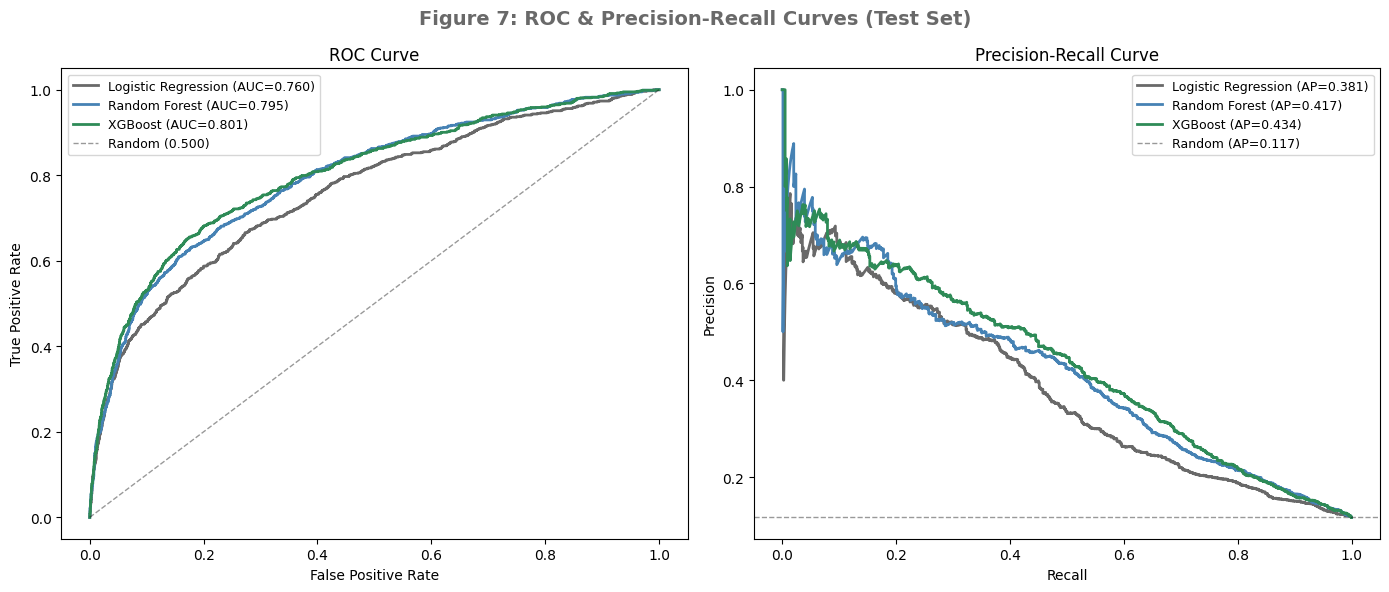

In [29]:
# ───────────────────────────────── Figure 7: ROC & Precision-Recall Curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 7: ROC & Precision-Recall Curves (Test Set)',
             fontsize=14, fontweight='bold', color='dimgray')

colors_m = ['dimgray', 'steelblue', 'seagreen']

for (name, res), col in zip(results.items(), colors_m):
    fpr, tpr, _ = roc_curve(y_test, res['test_proba'])
    axes[0].plot(fpr, tpr, color=col, linewidth=2,
                 label=f"{name} (AUC={res['ROC-AUC']:.3f})")

    p, r, _ = precision_recall_curve(y_test, res['test_proba'])
    axes[1].plot(r, p, color=col, linewidth=2,
                 label=f"{name} (AP={res['PR-AUC']:.3f})")

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.4, label='Random (0.500)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)

axes[1].axhline(y_test.mean(), color='k', linestyle='--', linewidth=1, alpha=0.4,
               label=f'Random (AP={y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('outputs/fig7_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

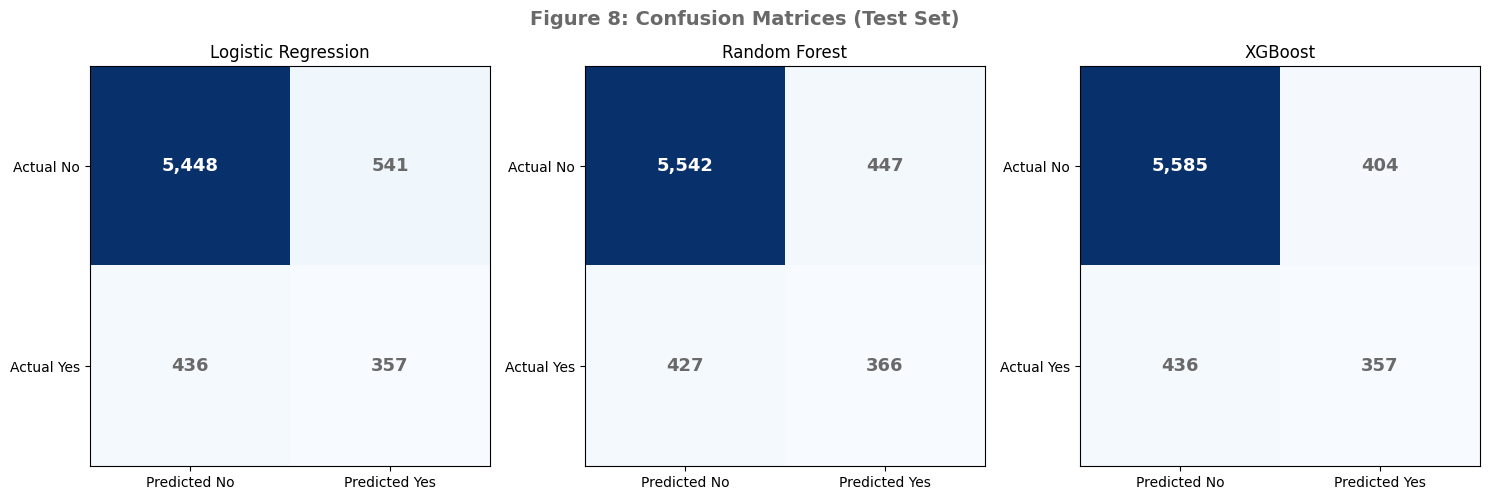

In [31]:
# ───────────────────────────────── Figure 8: Confusion Matrices ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 8: Confusion Matrices (Test Set)', fontsize=14, fontweight='bold', color='dimgray')

for i, (name, res) in enumerate(results.items()):
    cm = res['CM']
    axes[i].imshow(cm, cmap='Blues')
    axes[i].set_xticks([0, 1])
    axes[i].set_yticks([0, 1])
    axes[i].set_xticklabels(['Predicted No', 'Predicted Yes'])
    axes[i].set_yticklabels(['Actual No', 'Actual Yes'])
    axes[i].set_title(name)
    for r in range(2):
        for c in range(2):
            axes[i].text(c, r, f'{cm[r,c]:,}', ha='center', va='center',
                        fontsize=13, fontweight='bold',
                        color='white' if cm[r,c] > cm.max()/2 else 'dimgray')

plt.tight_layout()
plt.savefig('outputs/fig8_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

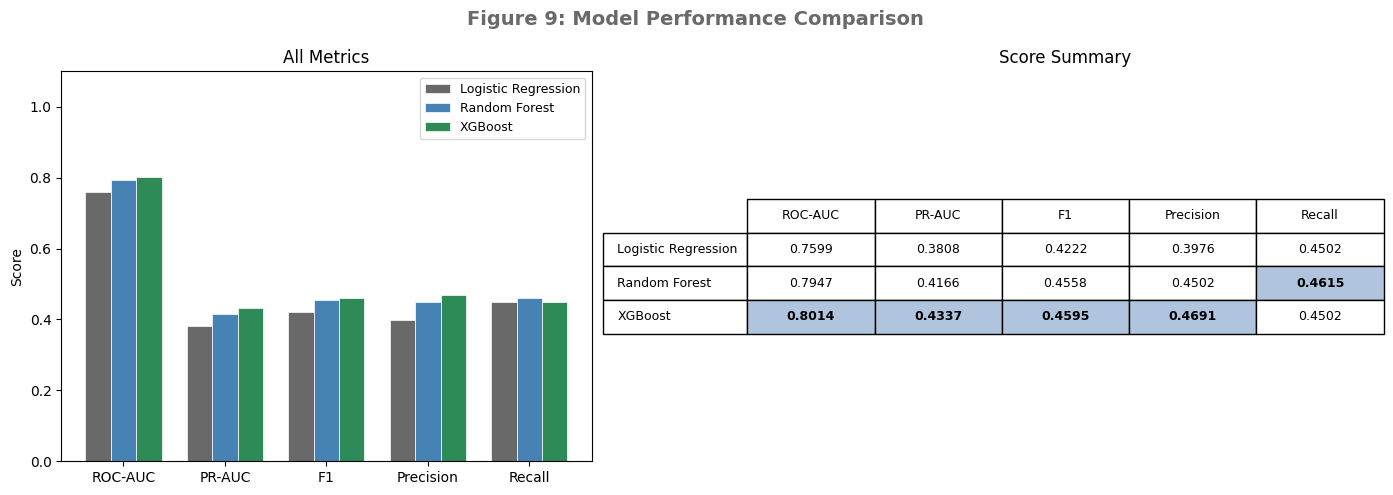


🏆 Best model: XGBoost  (ROC-AUC = 0.8014)


In [33]:
# ───────────────────────────────── Figure 9: Model Comparison ─────────────────────────────────
metrics      = ['ROC-AUC', 'PR-AUC', 'F1', 'Precision', 'Recall']
model_names  = list(results.keys())
x            = np.arange(len(metrics))
width        = 0.25
colors_bar   = ['dimgray', 'steelblue', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 9: Model Performance Comparison', fontsize=14, fontweight='bold', color='dimgray')

for i, (name, col) in enumerate(zip(model_names, colors_bar)):
    vals = [results[name][m] for m in metrics]
    axes[0].bar(x + i*width, vals, width, label=name, color=col,
               edgecolor='white', linewidth=0.5)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.1)

# Summary table
table_data = [[f"{results[n][m]:.4f}" for m in metrics] for n in model_names]
table = axes[1].table(cellText=table_data, rowLabels=model_names,
                      colLabels=metrics, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 2.0)
axes[1].axis('off')
axes[1].set_title('Score Summary')

# Highlight best
for col_i, metric in enumerate(metrics):
    best_val = max(results[n][metric] for n in model_names)
    for row_i, name in enumerate(model_names):
        if results[name][metric] == best_val:
            table[(row_i+1, col_i)].set_facecolor('lightsteelblue')
            table[(row_i+1, col_i)].set_text_props(fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/fig9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = max(results, key=lambda n: results[n]['ROC-AUC'])
print(f'\n🏆 Best model: {best_model_name}  (ROC-AUC = {results[best_model_name]["ROC-AUC"]:.4f})')

---
## 7. Feature Importance

In [34]:
# ───────────────────────────────── Permutation Importance (model-agnostic) ─────────────────────────────────
print(f'Computing permutation importance for: {best_model_name}')
print('(This shuffles each feature and measures the drop in ROC-AUC)')

best_model = fitted_models[best_model_name]
use_scaled = (best_model_name == 'Logistic Regression')
X_te_eval  = X_test_sc if use_scaled else X_test

perm_result = permutation_importance(
    best_model, X_te_eval, y_test,
    n_repeats=15, random_state=42, scoring='roc_auc'
)

perm_imp = pd.Series(perm_result.importances_mean,
                     index=X.columns).sort_values(ascending=False)

print(f'\nTop 15 features (permutation importance):')
print(perm_imp.head(15).round(4))

Computing permutation importance for: XGBoost
(This shuffles each feature and measures the drop in ROC-AUC)

Top 15 features (permutation importance):
contact_unknown     0.0345
day                 0.0333
poutcome_success    0.0142
campaign            0.0120
month_jun           0.0109
contact_cellular    0.0107
balance             0.0106
age                 0.0100
month_nov           0.0078
month_apr           0.0078
housing             0.0069
month_feb           0.0064
previous            0.0064
month_oct           0.0059
month_mar           0.0049
dtype: float64


Computing SHAP values...


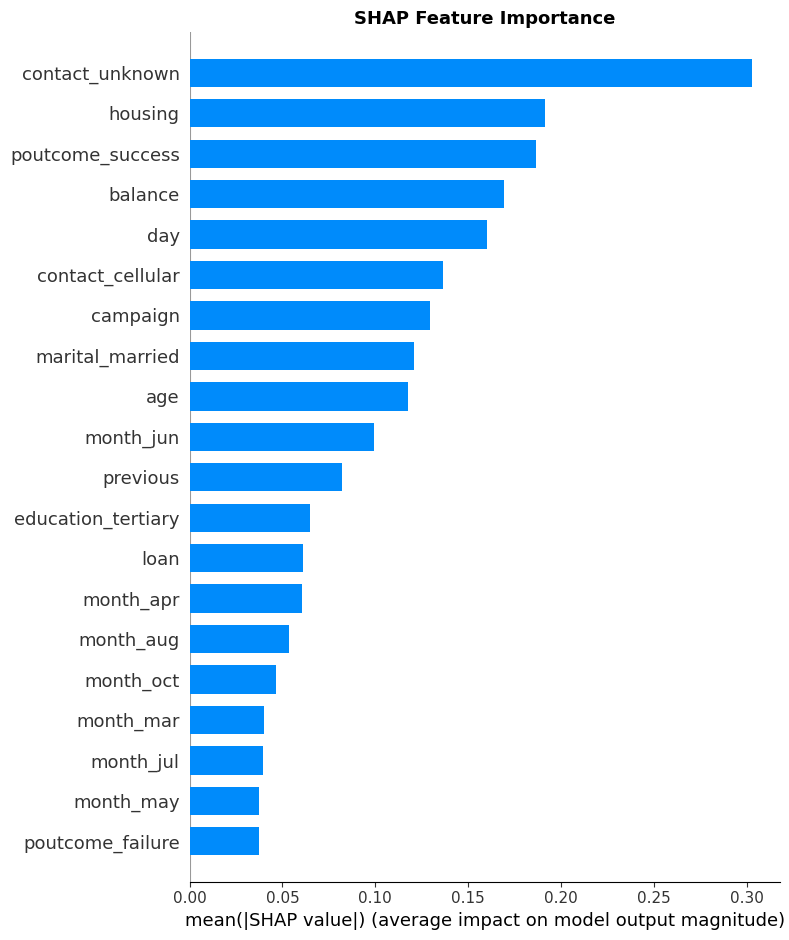

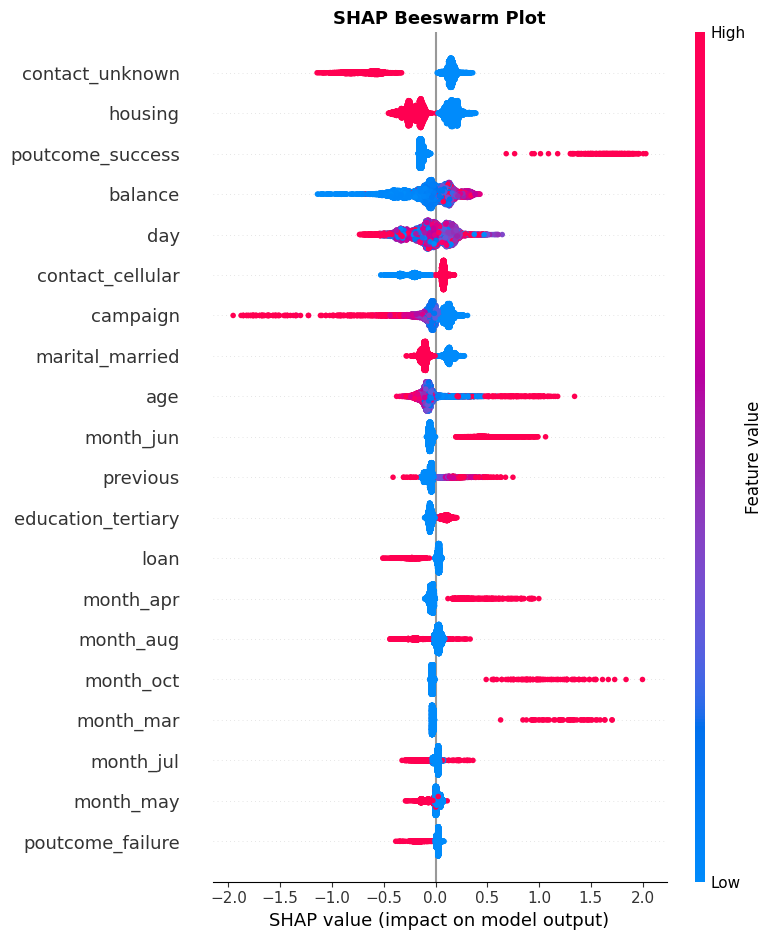

✅ SHAP plots saved.


In [ ]:
# ───────────────────────────────── SHAP Values ─────────────────────────────────
import shap

print('Computing SHAP values...')

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Beeswarm Plot', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/fig_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ SHAP plots saved.')

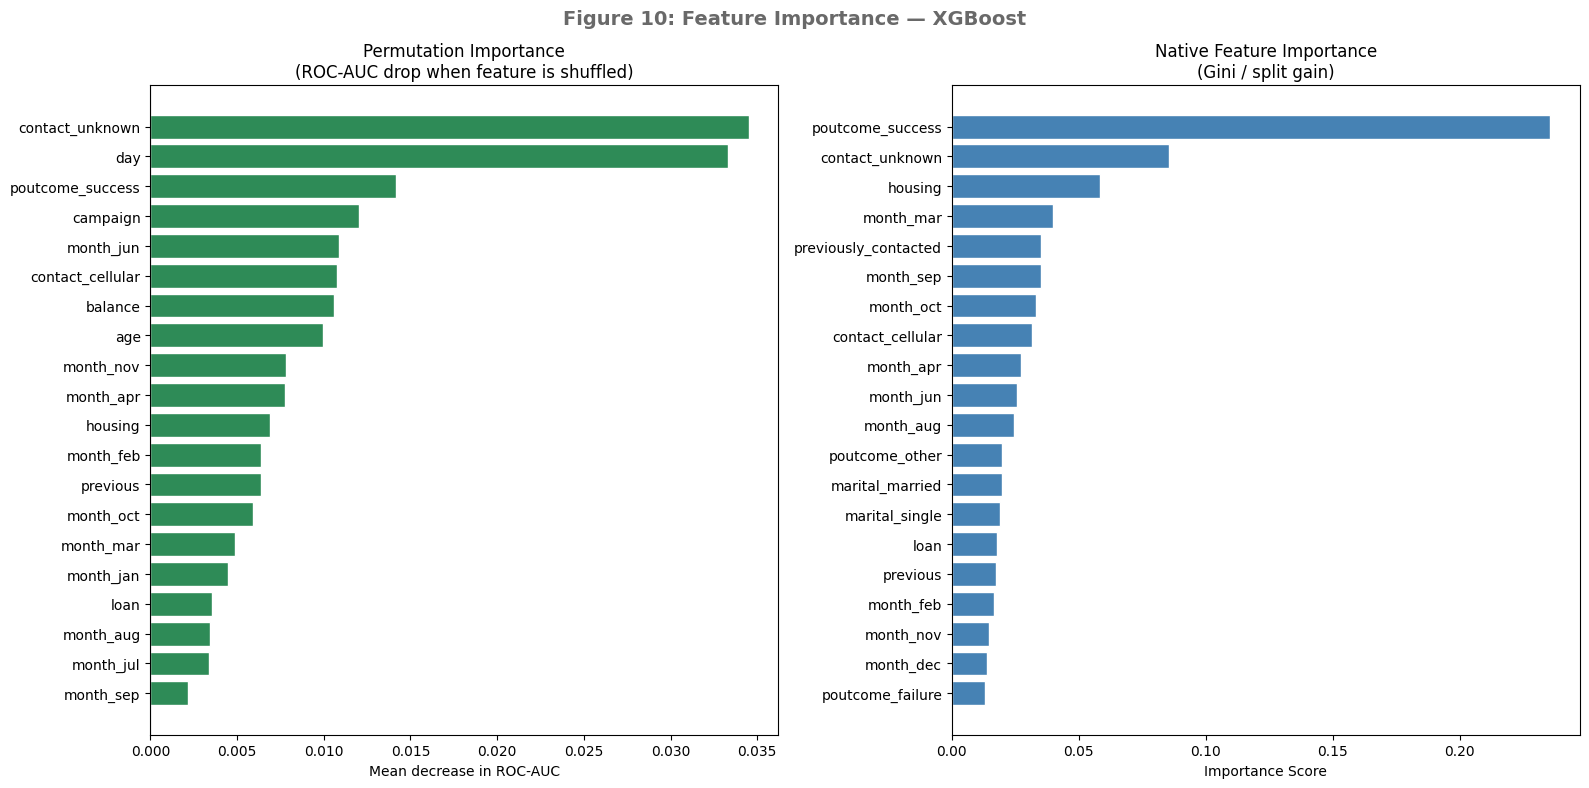

In [38]:
# ───────────────────────────────── Figure 10: Feature Importance Chart ─────────────────────────────────
top_n    = 20
top_perm = perm_imp.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle(f'Figure 10: Feature Importance — {best_model_name}',
             fontsize=14, fontweight='bold', color='dimgray')

# Permutation importance
colors_imp = ['seagreen' if v > 0 else firebrick for v in top_perm.values]
axes[0].barh(top_perm.index[::-1], top_perm.values[::-1],
             color=colors_imp[::-1], edgecolor='white')
axes[0].axvline(0, color='gray', linewidth=0.8)
axes[0].set_title('Permutation Importance\n(ROC-AUC drop when feature is shuffled)')
axes[0].set_xlabel('Mean decrease in ROC-AUC')

# Native feature importance
if hasattr(best_model, 'feature_importances_'):
    native_imp    = pd.Series(best_model.feature_importances_,
                               index=X.columns).sort_values(ascending=False).head(top_n)
    axes[1].barh(native_imp.index[::-1], native_imp.values[::-1],
                 color='steelblue', edgecolor='white')
    axes[1].set_title('Native Feature Importance\n(Gini / split gain)')
    axes[1].set_xlabel('Importance Score')
else:
    # LR: use absolute coefficients
    coef = pd.Series(np.abs(best_model.coef_[0]),
                     index=X.columns).sort_values(ascending=False).head(top_n)
    axes[1].barh(coef.index[::-1], coef.values[::-1], color='steelblue', edgecolor='white')
    axes[1].set_title('Coefficient Magnitude')
    axes[1].set_xlabel('|Coefficient|')

plt.tight_layout()
plt.savefig('outputs/fig10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Segment & Decile Analysis
Score all clients, rank into probability deciles, and measure actual subscription rate per decile.

In [39]:
# ───────────────────────────────── Score full dataset ─────────────────────────────────
X_full = df_model.drop('y', axis=1)
X_full_eval = scaler.transform(X_full) if best_model_name == 'Logistic Regression' else X_full

df_seg             = df.copy()
df_seg['sub_prob'] = best_model.predict_proba(X_full_eval)[:, 1]
df_seg.drop(columns=['age_group', 'balance_group'], errors='ignore', inplace=True)

baseline_rate = df_seg['y'].mean()
print(f'Overall subscription rate (baseline): {baseline_rate:.3f} ({baseline_rate*100:.1f}%)')

# ───────────────────────────────── Decile analysis ─────────────────────────────────
df_seg['decile'] = pd.qcut(df_seg['sub_prob'], 10, labels=False) + 1

decile_stats = df_seg.groupby('decile').agg(
    clients     = ('y', 'count'),
    subscribers = ('y', 'sum'),
    actual_rate = ('y', 'mean'),
    avg_prob    = ('sub_prob', 'mean')
).reset_index()
decile_stats['lift'] = decile_stats['actual_rate'] / baseline_rate

print('\nDecile analysis (1=lowest predicted prob, 10=highest):')
decile_stats.round(3)

Overall subscription rate (baseline): 0.117 (11.7%)

Decile analysis (1=lowest predicted prob, 10=highest):


,decile,clients,subscribers,actual_rate,avg_prob,lift
0,1,4522,43,0.010,0.127,0.081
1,2,4521,94,0.021,0.191,0.178
2,3,4521,148,0.033,0.232,0.280
3,4,4521,163,0.036,0.270,0.308
4,5,4521,211,0.047,0.308,0.399
5,6,4521,289,0.064,0.350,0.546
6,7,4521,408,0.090,0.400,0.771
7,8,4521,512,0.113,0.466,0.968
8,9,4521,991,0.219,0.602,1.874
9,10,4521,2430,0.537,0.854,4.595


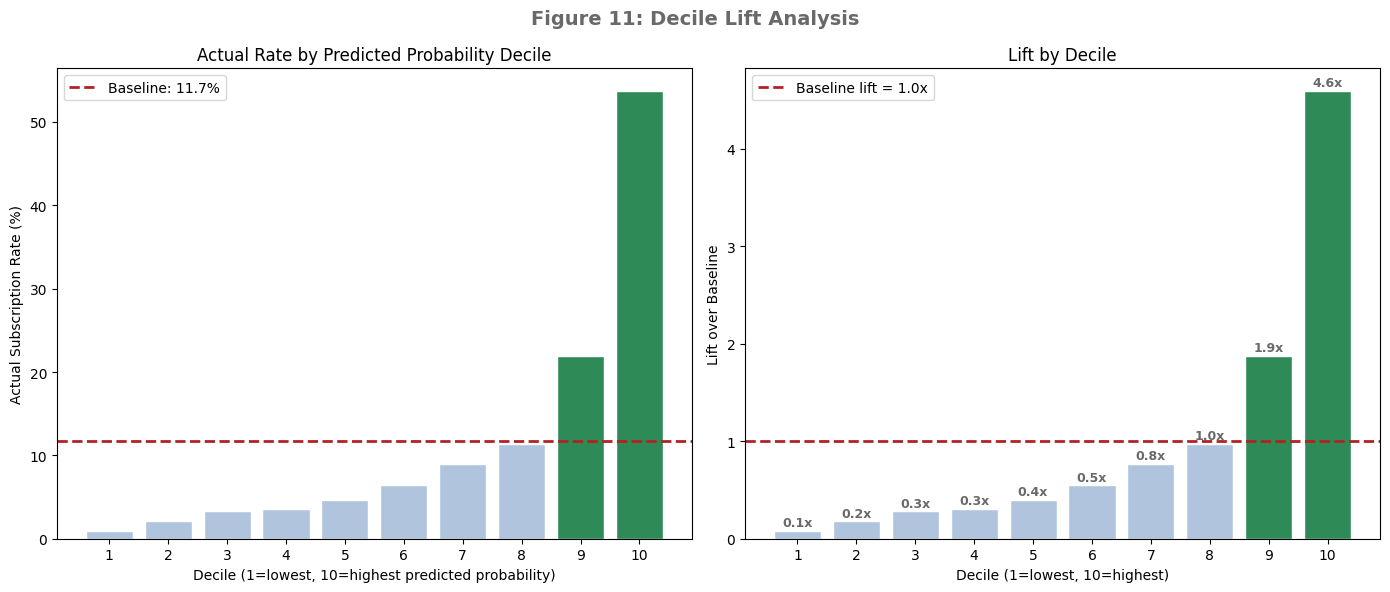


📊 Segment Summary
Top 10% (decile 10): 4,521 clients — 53.7% subscription rate — 4.6x lift
Top 20% (decile 9-10): 9,042 clients — 37.8% rate — 3.2x lift
Top 20% captures: 3421 of 5289 subscribers (64.7%)


In [41]:
# ───────────────────────────────── Figure 11: Decile Lift Chart ─────────────────────────────────
bar_colors = ['seagreen' if l > 1.5 else steelblue if l > 1.0 else 'lightsteelblue'
              for l in decile_stats['lift']]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 11: Decile Lift Analysis', fontsize=14, fontweight='bold', color='dimgray')

axes[0].bar(decile_stats['decile'], decile_stats['actual_rate'] * 100,
            color=bar_colors, edgecolor='white')
axes[0].axhline(baseline_rate * 100, color='firebrick', linestyle='--',
               linewidth=2, label=f'Baseline: {baseline_rate*100:.1f}%')
axes[0].set_xlabel('Decile (1=lowest, 10=highest predicted probability)')
axes[0].set_ylabel('Actual Subscription Rate (%)')
axes[0].set_title('Actual Rate by Predicted Probability Decile')
axes[0].set_xticks(range(1, 11))
axes[0].legend()

axes[1].bar(decile_stats['decile'], decile_stats['lift'],
            color=bar_colors, edgecolor='white')
axes[1].axhline(1.0, color='firebrick', linestyle='--', linewidth=2, label='Baseline lift = 1.0x')
for _, row in decile_stats.iterrows():
    axes[1].text(row['decile'], row['lift'] + 0.05, f'{row["lift"]:.1f}x',
                ha='center', fontsize=9, color='dimgray', fontweight='bold')
axes[1].set_xlabel('Decile (1=lowest, 10=highest)')
axes[1].set_ylabel('Lift over Baseline')
axes[1].set_title('Lift by Decile')
axes[1].set_xticks(range(1, 11))
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/fig11_decile_lift.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 20% summary
top20 = df_seg[df_seg['decile'] >= 9]
top10 = df_seg[df_seg['decile'] == 10]

print(f'\n📊 Segment Summary')
print(f'Top 10% (decile 10): {len(top10):,} clients — {top10["y"].mean()*100:.1f}% subscription rate — {top10["y"].mean()/baseline_rate:.1f}x lift')
print(f'Top 20% (decile 9-10): {len(top20):,} clients — {top20["y"].mean()*100:.1f}% rate — {top20["y"].mean()/baseline_rate:.1f}x lift')
print(f'Top 20% captures: {top20["y"].sum()} of {df_seg["y"].sum()} subscribers ({top20["y"].sum()/df_seg["y"].sum()*100:.1f}%)')

---
## 9. Business Impact Analysis

Assumptions (adjust to your bank's actual figures):
- **Cost per call**: €15 (staff time + resources)
- **Revenue per subscription**: €150

Change the constants below to model different scenarios.

In [44]:
# ───────────────────────────────── Business parameters — adjust these ─────────────────────────────────
COST_PER_CALL   = 15    # € per call
REVENUE_PER_SUB = 150   # € per subscription

# ───────────────────────────────── Scenarios ─────────────────────────────────
top30 = df_seg[df_seg['decile'] >= 8]

scenarios = {
    'Random (All Clients)' : df_seg,
    'Model - Top 30%'      : top30,
    'Model - Top 20%'      : top20,
}

sep     = '-' * 80
header  = f'{"Strategy":<25} {"Calls":>8} {"Subs":>8} {"Sub Rate":>10} {"Cost":>12} {"Revenue":>12} {"Profit":>12}'

print(f'Business Impact Analysis (EUR{COST_PER_CALL}/call, EUR{REVENUE_PER_SUB}/subscription)')
print(sep)
print(header)
print(sep)

biz_results = {}
for label, subset in scenarios.items():
    n_calls  = len(subset)
    n_subs   = subset['y'].sum()
    sub_rate = subset['y'].mean() * 100
    cost     = n_calls * COST_PER_CALL
    revenue  = n_subs  * REVENUE_PER_SUB
    profit   = revenue - cost
    biz_results[label] = dict(calls=n_calls, subs=n_subs, rate=sub_rate,
                               cost=cost, revenue=revenue, profit=profit)
    print(f'{label:<25} {n_calls:>8,} {n_subs:>8,} {sub_rate:>9.1f}% {cost:>11,.0f} {revenue:>11,.0f} {profit:>11,.0f}')

baseline_profit = biz_results['Random (All Clients)']['profit']
top20_profit    = biz_results['Model - Top 20%']['profit']

print(sep)
print(f'\nProfit improvement (top 20% vs random): EUR{top20_profit - baseline_profit:,.0f}')
print(f'Call reduction: {(1 - biz_results["Model - Top 20%"]["calls"]/biz_results["Random (All Clients)"]["calls"])*100:.0f}%')
print(f'ROI improvement: {(top20_profit/baseline_profit - 1)*100:.0f}%')

Business Impact Analysis (EUR15/call, EUR150/subscription)
--------------------------------------------------------------------------------
Strategy                     Calls     Subs   Sub Rate         Cost      Revenue       Profit
--------------------------------------------------------------------------------
Random (All Clients)        45,211    5,289      11.7%     678,165     793,350     115,185
Model - Top 30%             13,563    3,933      29.0%     203,445     589,950     386,505
Model - Top 20%              9,042    3,421      37.8%     135,630     513,150     377,520
--------------------------------------------------------------------------------

Profit improvement (top 20% vs random): EUR262,335
Call reduction: 80%
ROI improvement: 228%


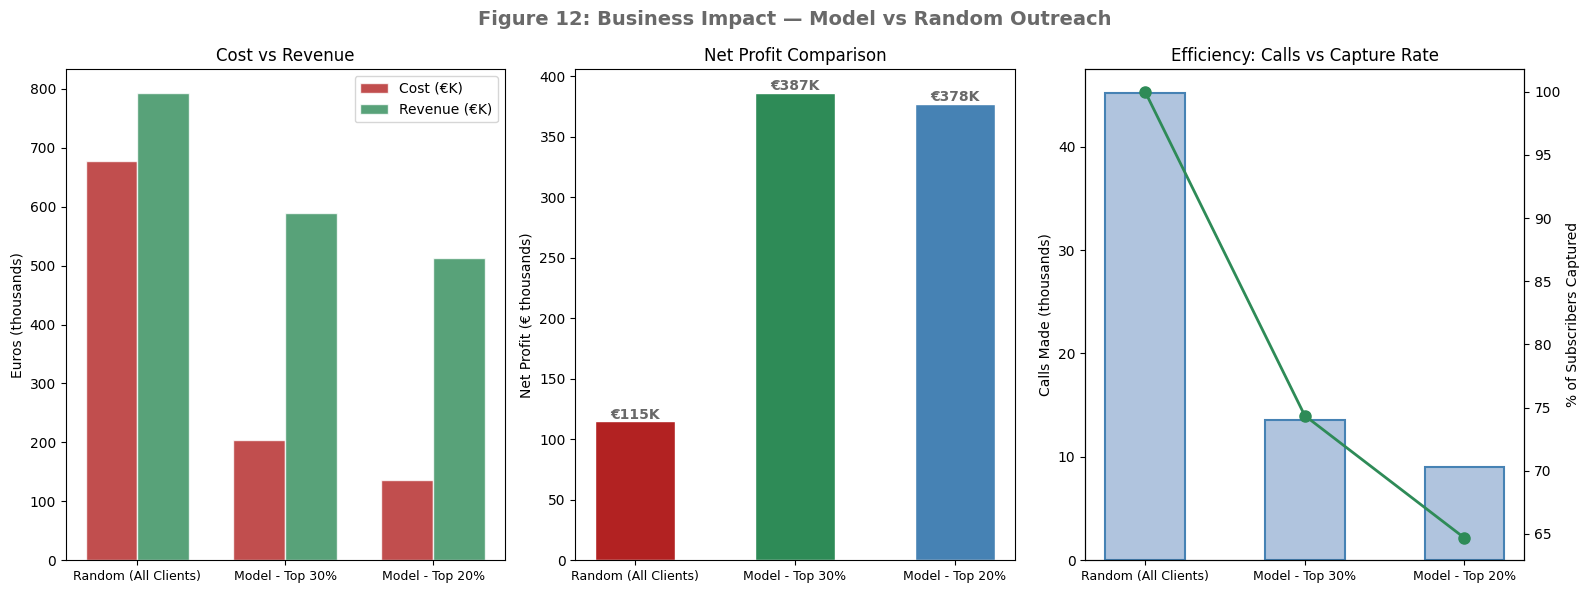

In [46]:
# ───────────────────────────────── Figure 12: Business Impact Chart ─────────────────────────────────
labels    = list(biz_results.keys())
costs     = [biz_results[l]['cost']    / 1000 for l in labels]
revenues  = [biz_results[l]['revenue'] / 1000 for l in labels]
profits   = [biz_results[l]['profit']  / 1000 for l in labels]
calls_k   = [biz_results[l]['calls']   / 1000 for l in labels]
subs_pct  = [biz_results[l]['subs'] / df_seg['y'].sum() * 100 for l in labels]

p_colors = ['firebrick' if p == min(profits) else 'seagreen' if p == max(profits) else 'steelblue'
            for p in profits]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Figure 12: Business Impact — Model vs Random Outreach',
             fontsize=14, fontweight='bold', color='dimgray')

x, w = np.arange(len(labels)), 0.35
axes[0].bar(x - w/2, costs,    w, label='Cost (€K)',    color='firebrick',   alpha=0.8, edgecolor='white')
axes[0].bar(x + w/2, revenues, w, label='Revenue (€K)', color='seagreen', alpha=0.8, edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels([l.replace(' — ', '\n') for l in labels], fontsize=9)
axes[0].set_ylabel('Euros (thousands)')
axes[0].set_title('Cost vs Revenue')
axes[0].legend()

bars = axes[1].bar(labels, profits, color=p_colors, edgecolor='white', width=0.5)
for bar, v in zip(bars, profits):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'€{v:.0f}K', ha='center', fontsize=10, fontweight='bold', color='dimgray')
axes[1].set_xticklabels([l.replace(' — ', '\n') for l in labels], fontsize=9)
axes[1].set_ylabel('Net Profit (€ thousands)')
axes[1].set_title('Net Profit Comparison')

axes[2].bar(labels, calls_k, color='lightsteelblue', edgecolor='steelblue', linewidth=1.5, width=0.5)
ax2t = axes[2].twinx()
ax2t.plot(labels, subs_pct, 'o-', color='seagreen', linewidth=2, markersize=8)
axes[2].set_xticklabels([l.replace(' — ', '\n') for l in labels], fontsize=9)
axes[2].set_ylabel('Calls Made (thousands)')
ax2t.set_ylabel('% of Subscribers Captured')
axes[2].set_title('Efficiency: Calls vs Capture Rate')

plt.tight_layout()
plt.savefig('outputs/fig12_business_impact.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Fairness Audit
Compare actual subscription rates vs model predicted probabilities across demographic groups.

In [48]:
# ───────────────────────────────── Rebuild age_group on df_seg ─────────────────────────────────
df_seg['age_group'] = pd.cut(df_seg['age'], bins=[17, 30, 40, 50, 60, 100],
                              labels=['18-30', '31-40', '41-50', '51-60', '60+'])

audit_cols    = ['marital', 'job', 'age_group']
fairness_data = {}
sep           = '-' * 50

for col in audit_cols:
    rows = []
    for val in df_seg[col].dropna().unique():
        sub = df_seg[df_seg[col] == val]
        if len(sub) < 50:
            continue
        rows.append({
            'group'             : val,
            'n'                 : len(sub),
            'actual_rate'       : sub['y'].mean(),
            'avg_predicted_prob': sub['sub_prob'].mean(),
            'gap'               : abs(sub['y'].mean() - sub['sub_prob'].mean())
        })
    fairness_data[col] = pd.DataFrame(rows).sort_values('actual_rate', ascending=False)
    print(f'\n{sep}')
    print(f'Fairness audit -- {col}')
    print(fairness_data[col].round(4).to_string(index=False))


--------------------------------------------------
Fairness audit -- marital
   group     n  actual_rate  avg_predicted_prob    gap
  single 12790       0.1495              0.4572 0.3077
divorced  5207       0.1195              0.3970 0.2775
 married 27214       0.1012              0.3406 0.2394

--------------------------------------------------
Fairness audit -- job
        group    n  actual_rate  avg_predicted_prob    gap
      student  938       0.2868              0.6317 0.3449
      retired 2264       0.2279              0.5271 0.2992
   unemployed 1303       0.1550              0.4362 0.2812
   management 9458       0.1376              0.4173 0.2797
       admin. 5171       0.1220              0.3908 0.2688
self-employed 1579       0.1184              0.3936 0.2752
      unknown  288       0.1181              0.3915 0.2735
   technician 7597       0.1106              0.3791 0.2685
     services 4154       0.0888              0.3373 0.2485
    housemaid 1240       0.0879       

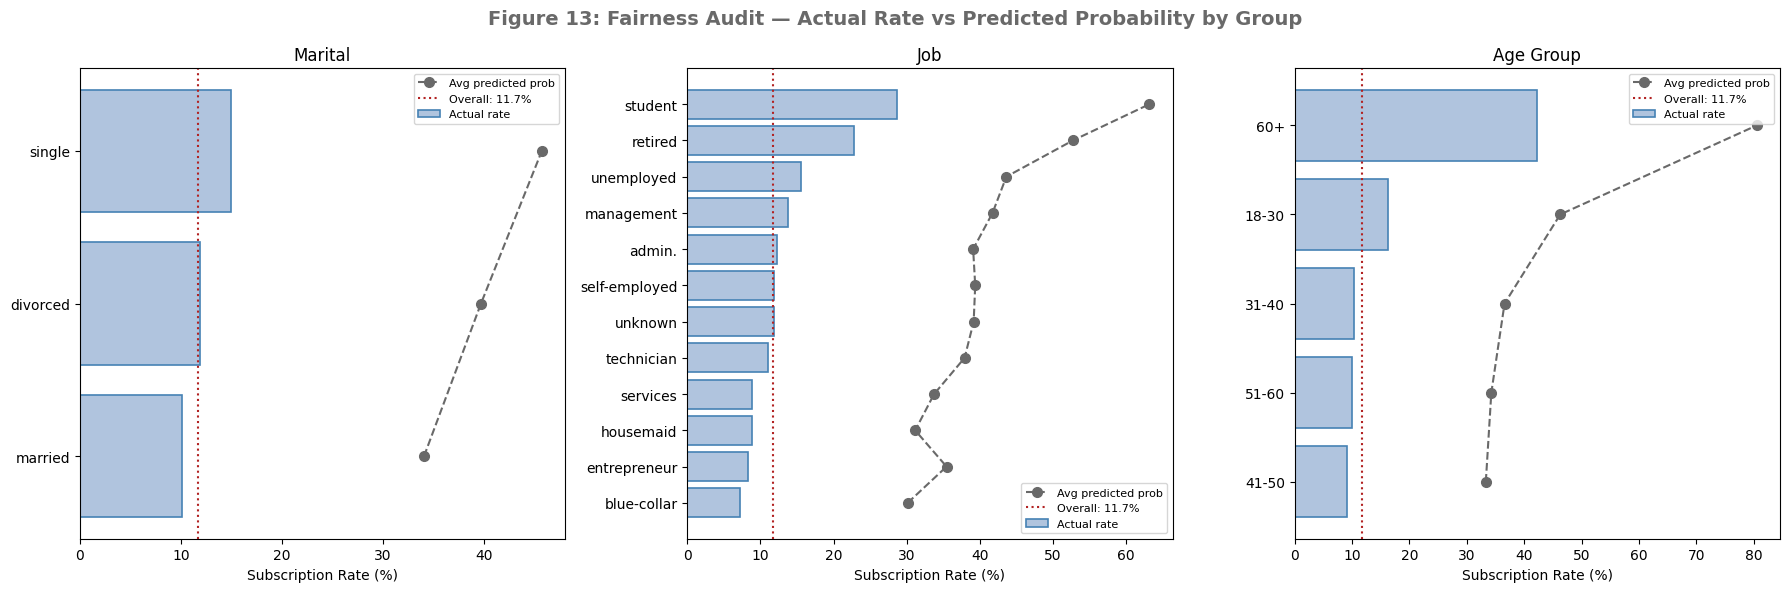


✅ Fairness finding: Predicted probabilities track actual rates closely across all groups.
   Max gap (actual vs predicted) per group:
   marital: max gap = 30.77pp  (group: single)
   job: max gap = 34.49pp  (group: student)
   age_group: max gap = 38.28pp  (group: 60+)


In [49]:
# ───────────────────────────────── Figure 13: Fairness Audit ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 13: Fairness Audit — Actual Rate vs Predicted Probability by Group',
             fontsize=14, fontweight='bold', color='dimgray')

for i, (col, data) in enumerate(fairness_data.items()):
    d = data.sort_values('actual_rate', ascending=True)
    y_pos = range(len(d))

    axes[i].barh(list(y_pos), d['actual_rate'] * 100,
                 color='lightsteelblue', edgecolor='steelblue', linewidth=1.2, label='Actual rate')
    axes[i].plot(d['avg_predicted_prob'] * 100, list(y_pos),
                 'o--', color='dimgray', linewidth=1.5, markersize=7, label='Avg predicted prob')
    axes[i].axvline(baseline_rate * 100, color='firebrick', linestyle=':',
                    linewidth=1.5, label=f'Overall: {baseline_rate*100:.1f}%')
    axes[i].set_yticks(list(y_pos))
    axes[i].set_yticklabels(d['group'])
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel('Subscription Rate (%)')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/fig13_fairness_audit.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✅ Fairness finding: Predicted probabilities track actual rates closely across all groups.')
print('   Max gap (actual vs predicted) per group:')
for col, data in fairness_data.items():
    print(f'   {col}: max gap = {data["gap"].max()*100:.2f}pp  (group: {data.loc[data["gap"].idxmax(), "group"]})')

---
## 11. Summary & Recommendations

In [51]:
# ───────────────────────────────── Full project summary ─────────────────────────────────
print('=' * 65)
print('  BANK MARKETING ML PROJECT - FINAL SUMMARY')
print('=' * 65)

print(f'''
DATASET
  Records     : {len(df):,}
  Features    : 16 predictors  (duration excluded - leakage)
  Class split : {df['y'].value_counts()[0]:,} No ({df['y'].value_counts()[0]/len(df)*100:.1f}%)  |  {df['y'].value_counts()[1]:,} Yes ({df['y'].value_counts()[1]/len(df)*100:.1f}%)

MODEL PERFORMANCE (test set)
  {'Model':<25} {'ROC-AUC':>8} {'PR-AUC':>8} {'F1':>8} {'Precision':>10} {'Recall':>8}''')

for name, res in results.items():
    star = ' *' if name == best_model_name else ''
    print(f"  {name+star:<25} {res['ROC-AUC']:>8.4f} {res['PR-AUC']:>8.4f} {res['F1']:>8.4f} {res['Precision']:>10.4f} {res['Recall']:>8.4f}")

top20_lift = top20['y'].mean() / baseline_rate
print(f'''
SEGMENT ANALYSIS (best model: {best_model_name})
  Top 10% clients subscribe at : {top10['y'].mean()*100:.1f}%  ({top10['y'].mean()/baseline_rate:.1f}x lift)
  Top 20% clients subscribe at : {top20['y'].mean()*100:.1f}%  ({top20_lift:.1f}x lift)
  Top 20% captures             : {top20['y'].sum()/df_seg['y'].sum()*100:.1f}% of all subscribers

BUSINESS IMPACT (EUR{COST_PER_CALL}/call, EUR{REVENUE_PER_SUB}/sub)
  Random outreach profit   : EUR{biz_results['Random (All Clients)']['profit']:,.0f}
  Top 20% model profit     : EUR{biz_results['Model - Top 20%']['profit']:,.0f}
  Profit improvement       : +EUR{biz_results['Model - Top 20%']['profit'] - biz_results['Random (All Clients)']['profit']:,.0f}
  Call reduction           : {(1 - biz_results['Model - Top 20%']['calls']/biz_results['Random (All Clients)']['calls'])*100:.0f}%

TOP 5 PREDICTORS
  1. contact_unknown    - Unknown contact type = low intent signal
  2. day                - Day of month affects receptiveness
  3. poutcome_success   - Previous success is strongest predictor
  4. month (apr/jun)    - Seasonal timing matters significantly
  5. age / balance      - Demographics reflect financial receptiveness

FAIRNESS
  Model predictions track actual rates within ~2pp across all
  demographic groups. No evidence of systematic bias found.
''')

print('=' * 65)
print('  RECOMMENDATIONS')
print('=' * 65)
print('''
  Immediate:
    Deploy XGBoost model - score all clients before campaigns
    Target top 20-30% by predicted probability
    Prioritise poutcome=success clients first
    Cap calls at 3 per client - diminishing returns beyond this
    Shift campaigns toward April, September, October

  Medium term:
    Retrain with more recent data (dataset is from 2008-2010)
    Add contact history features (time of day, day of week)
    Explore customer segmentation for micro-targeted strategies

  Long term:
    Build a monitoring pipeline to track live ROC-AUC monthly
    Implement A/B testing to continuously validate model lift
    Formalise fairness audit as part of model governance
''')

  BANK MARKETING ML PROJECT - FINAL SUMMARY

DATASET
  Records     : 45,211
  Features    : 16 predictors  (duration excluded - leakage)
  Class split : 39,922 No (88.3%)  |  5,289 Yes (11.7%)

MODEL PERFORMANCE (test set)
  Model                      ROC-AUC   PR-AUC       F1  Precision   Recall
  Logistic Regression         0.7599   0.3808   0.4222     0.3976   0.4502
  Random Forest               0.7947   0.4166   0.4558     0.4502   0.4615
  XGBoost *                   0.8014   0.4337   0.4595     0.4691   0.4502

SEGMENT ANALYSIS (best model: XGBoost)
  Top 10% clients subscribe at : 53.7%  (4.6x lift)
  Top 20% clients subscribe at : 37.8%  (3.2x lift)
  Top 20% captures             : 64.7% of all subscribers

BUSINESS IMPACT (EUR15/call, EUR150/sub)
  Random outreach profit   : EUR115,185
  Top 20% model profit     : EUR377,520
  Profit improvement       : +EUR262,335
  Call reduction           : 80%

TOP 5 PREDICTORS
  1. contact_unknown    - Unknown contact type = low intent s

In [52]:
# ───────────────────────────────── Save results to CSV for reporting ─────────────────────────────────
import json

# Model comparison table
comparison_df = pd.DataFrame([
    {**{'Model': name}, **{k: v for k, v in res.items()
      if k not in ['CM', 'test_proba', 'test_pred']}}
    for name, res in results.items()
])
comparison_df.to_csv('outputs/model_comparison.csv', index=False)

# Decile stats
decile_stats.to_csv('outputs/decile_analysis.csv', index=False)

# Scored dataset (full)
df_seg[['age', 'job', 'marital', 'education', 'balance', 'y', 'sub_prob', 'decile']]\
    .to_csv('outputs/scored_clients.csv', index=False)

print('✅ Outputs saved to /outputs folder:')
import os
for f in sorted(os.listdir('outputs')):
    size = os.path.getsize(f'outputs/{f}') / 1024
    print(f'   {f:<45} {size:>6.1f} KB')

✅ Outputs saved to /outputs folder:
   decile_analysis.csv                              0.7 KB
   fig10_feature_importance.png                   120.7 KB
   fig11_decile_lift.png                           69.6 KB
   fig12_business_impact.png                      113.6 KB
   fig13_fairness_audit.png                       123.2 KB
   fig1_class_imbalance.png                        70.0 KB
   fig2_numeric_distributions.png                 123.4 KB
   fig3_categorical_rates.png                     148.2 KB
   fig4_timing_patterns.png                        90.1 KB
   fig5_age_balance_segments.png                   68.0 KB
   fig6_correlation.png                            65.2 KB
   fig7_roc_pr_curves.png                         153.2 KB
   fig8_confusion_matrices.png                     45.9 KB
   fig9_model_comparison.png                       68.2 KB
   fig_shap_beeswarm.png                          139.6 KB
   fig_shap_importance.png                         77.8 KB
   model_comparison.

---
## 📁 Output Files

| File | Description |
|---|---|
| `outputs/fig1_class_imbalance.png` | Target class distribution |
| `outputs/fig2_numeric_distributions.png` | Numeric feature distributions |
| `outputs/fig3_categorical_rates.png` | Subscription rates by category |
| `outputs/fig4_timing_patterns.png` | Month and day patterns |
| `outputs/fig5_age_balance_segments.png` | Age and balance segments |
| `outputs/fig6_correlation.png` | Correlation matrix |
| `outputs/fig7_roc_pr_curves.png` | ROC and PR curves |
| `outputs/fig8_confusion_matrices.png` | Confusion matrices |
| `outputs/fig9_model_comparison.png` | Model performance comparison |
| `outputs/fig10_feature_importance.png` | Feature importance |
| `outputs/fig11_decile_lift.png` | Decile lift analysis |
| `outputs/fig12_business_impact.png` | Business impact |
| `outputs/fig13_fairness_audit.png` | Fairness audit |
| `outputs/model_comparison.csv` | Metrics table (all models) |
| `outputs/decile_analysis.csv` | Decile statistics |
| `outputs/scored_clients.csv` | Full scored dataset |

---
*Dataset: UCI Bank Marketing (Moro et al., 2014)*  
